# Portfolio Risk and Monte Carlo Simulation

In finance, risk management relies heavily on understanding the probability of adverse market movements. Unlike the Monty Hall problem, which has a discrete and easily calculable probability space, financial markets are continuous, complex, and stochastic (random). 

To model this uncertainty, quantitative analysts use **Monte Carlo simulations** to generate thousands of potential future market scenarios. By analyzing the distribution of these simulated outcomes, we can quantify risk using industry-standard metrics.

In this notebook, we will:
1. Simulate future asset prices using **Geometric Brownian Motion (GBM)**.
2. Calculate the **Value at Risk (VaR)** to understand our maximum expected loss.
3. Calculate the **Conditional Value at Risk (CVaR / Expected Shortfall)** to measure the severity of tail-risk events.

---

## 1. Defining the Simulation Parameters

Before we run our simulations, we need to establish the ground rules. Here, we define a configuration dictionary that sets our starting wealth, annual contribution, expected market return, market volatility (sigma), investment time horizon, number of simulations to run, and our ultimate retirement goal.

In [ ]:
CONFIG = {
    "start_money" :         10_000,
    "yearly_invest" :       5_000,
    "market_avg_return" :   0.07,
    "sigma" :               0.15,
    "years" :               30,
    "n_sims" :              1000,
    "retirement_goal":      2_500_000
}

## 2. Visualizing Wealth Projections (Standard Simulation)

Now that we have our parameters, we can run our first Monte Carlo simulation. This initial pass will generate 1,000 potential paths our portfolio could take over the next 30 years.

We will plot all 1,000 paths faintly in the background to show the vast range of possibilities. To make sense of the noise, we overlay three key lines:

* **The Median Path (Blue):** The middle-of-the-road expectation.
* **The 5th Percentile (Red):** Our worst-case scenario (a simplified look at VaR).
* **The Principal Value (Yellow):** The total amount of cash we actually deposited, completely ignoring market returns.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
def wealth_simulator(config):
    
    w0 = config["start_money"]
    yearly_invest = config["yearly_invest"]
    mu = config["market_avg_return"]
    sigma = config["sigma"]
    years = config["years"]
    n_sims = config["n_sims"]

    wealth_paths = np.zeros((years + 1, n_sims))
    wealth_paths[0] = w0
    
    for t in range(1, years + 1):
        # Generate random returns for all 1000 sims at once for this year
        returns = np.random.normal(loc=mu, scale=sigma, size=n_sims)
        
        # Calculate new wealth: (Previous Wealth + Contribution) * (1 + Return)
        wealth_paths[t] = (wealth_paths[t-1] + yearly_invest) * (1 + returns)
        
    return wealth_paths

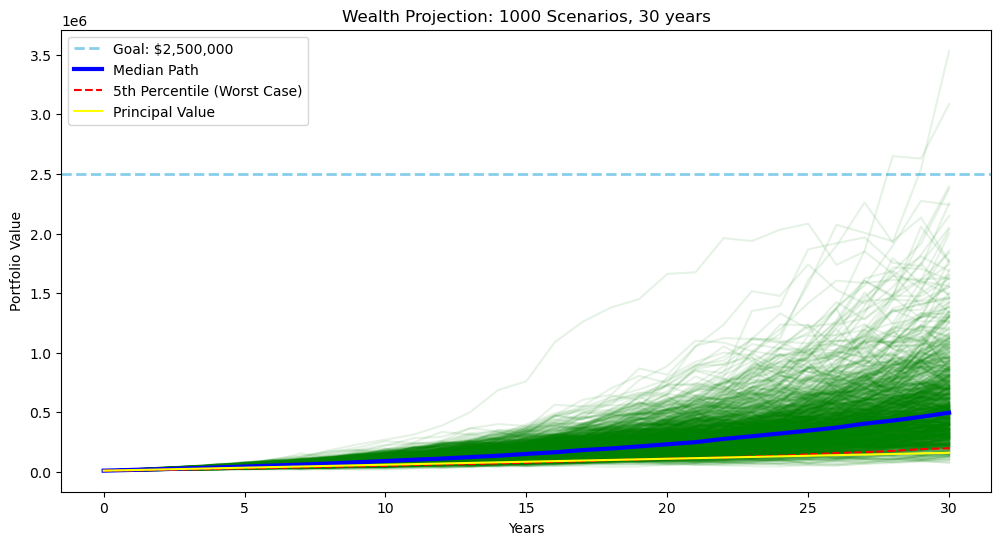

Median Final Wealth:            $496,334.23
5th Percentile (Poor outcome):  $197,995.41
95th Percentile (Rich outcome): $1,304,011.27
Principal value:                $160,000.00
Probability of Success:         0.20%


In [104]:
results = wealth_simulator(CONFIG)
# Principal value
years_array = np.arange(CONFIG["years"] + 1)
principal = CONFIG["start_money"] + CONFIG["yearly_invest"] * years_array

# Plotting
plt.figure(figsize=(12, 6))

plt.axhline(CONFIG["retirement_goal"], color='skyblue', linestyle='--', linewidth=2, 
            label=f'Goal: ${CONFIG["retirement_goal"]:,}')
plt.plot(results, color='green', alpha=0.1) # Plot all paths faintly
plt.plot(np.median(results, axis=1), color='blue', linewidth=3, label='Median Path')
plt.plot(np.percentile(results, 5, axis=1), color='red', linestyle='--', label='5th Percentile (Worst Case)')
plt.plot(principal, color = "yellow" ,label = "Principal Value")
plt.title(f"Wealth Projection: {CONFIG['n_sims']} Scenarios, {CONFIG['years']} years")
plt.xlabel("Years")
plt.ylabel("Portfolio Value")
plt.legend()
plt.show()


final_wealth = results[-1]
prob_success = np.sum(final_wealth >= CONFIG["retirement_goal"]) / CONFIG["n_sims"] * 100
print(f"Median Final Wealth:            ${np.median(final_wealth):,.2f}")
print(f"5th Percentile (Poor outcome):  ${np.percentile(final_wealth, 5):,.2f}")
print(f"95th Percentile (Rich outcome): ${np.percentile(final_wealth, 95):,.2f}")
print(f"Principal value:                ${principal[-1]:,.2f}")
print(f"Probability of Success:         {prob_success:.2f}%")

## 3. Modeling Asset Prices with Geometric Brownian Motion (Log-Adjusted)

Our first simulation was a good start, but financial markets don't grow linearly; they compound stochastically. To model future stock prices more accurately, we must use a form of **Geometric Brownian Motion (GBM)**.

GBM is the standard stochastic process used in options pricing because it ensures that asset prices never drop below zero and properly accounts for volatility drag over time.

The continuous-time model for GBM requires adjusting our expected return ($\mu$) by subtracting half the variance ($0.5 \times \sigma^2$). This adjustment translates our arithmetic mean return into a geometric mean return, which is essential for multi-period compounding.

$$\text{Adjusted Return} = \mu - \frac{1}{2}\sigma^2$$

In the code below, we define a new simulator that applies this log-normal adjustment and generates returns using the exponential function.


In [ ]:
def log_normal_wealth_simulator(config):  

    w0 = config["start_money"]
    yearly_invest = config["yearly_invest"]
    mu = config["market_avg_return"]
    sigma = config["sigma"]
    years = config["years"]
    n_sims = config["n_sims"]

    market_avg_return_adj = mu - 0.5 * sigma**2
    
    wealth_paths = np.zeros((years + 1, n_sims))
    wealth_paths[0] = w0
    
    for t in range(1, years + 1):
        returns = np.random.normal(loc=market_avg_return_adj, scale=sigma, size=n_sims)
        
        
        wealth_paths[t] = (wealth_paths[t-1] + yearly_invest) * np.exp(returns)
        
    return wealth_paths


## 4. Visualizing Log-Normal Risk and Success Probabilities

Finally, we run our mathematically rigorous `log_normal_wealth_simulator`.

Because compound growth creates an exponential curve, plotting these results on a standard linear axis can make the early years impossible to read and the later years look overly extreme. By setting the y-axis to a **logarithmic scale** (`plt.yscale('log')`), exponential growth appears as a straight line, making it much easier to compare performance trajectories across different scenarios.

The final output provides a realistic look at:
* **The 5th Percentile Outcome:** A proxy for Value at Risk (VaR), showing the "worst-case" expectation.
* **The Retirement Goal:** A clear visual of our success rate against the $2.5M target.
* **Success Probability:** The percentage of simulated paths that successfully reached or exceeded the goal.

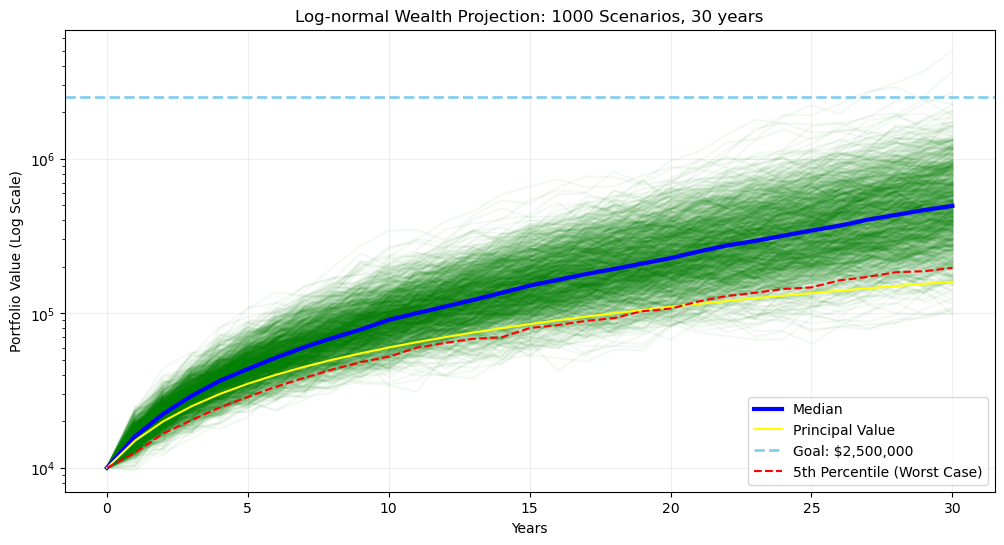

Median Final Wealth:                        $494,821.25
5th Percentile (Poor outcome):              $196,420.19
95th Percentile (Rich outcome):             $1,232,644.08
Principal value:                            $160,000.00
Probability of reaching retirement goal:    0.30%


In [108]:
results = log_normal_wealth_simulator(CONFIG)

# Principal value
years_array = np.arange(CONFIG["years"] + 1)
principal = CONFIG["start_money"] + CONFIG["yearly_invest"] * years_array

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(results, color='green', alpha=0.05)
plt.plot(np.median(results, axis=1), color='blue', linewidth=3, label='Median')
plt.plot(principal, color = "yellow" , label = "Principal Value")
plt.axhline(CONFIG["retirement_goal"], color='skyblue', linestyle='--', linewidth=2, 
            label=f'Goal: ${CONFIG["retirement_goal"]:,}')
plt.plot(np.percentile(results, 5, axis=1), color='red', linestyle='--', label='5th Percentile (Worst Case)')

plt.yscale('log')
plt.title(f"Log-normal Wealth Projection: {CONFIG['n_sims']} Scenarios, {CONFIG['years']} years")
plt.ylabel("Portfolio Value (Log Scale)")
plt.xlabel("Years")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()


final_wealth = results[-1]
prob_success = np.sum(final_wealth >= CONFIG["retirement_goal"]) / CONFIG["n_sims"] * 100

print(f"Median Final Wealth:                        ${np.median(final_wealth):,.2f}")
print(f"5th Percentile (Poor outcome):              ${np.percentile(final_wealth, 5):,.2f}")
print(f"95th Percentile (Rich outcome):             ${np.percentile(final_wealth, 95):,.2f}")
print(f"Principal value:                            ${principal[-1]:,.2f}")
print(f"Probability of reaching retirement goal:    {prob_success:.2f}%")